In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


from sklearn.model_selection import train_test_split

from quotaclimat.data_processing.factiva.explo_optimal_thresholds.utils_explo.utils_explo import (
    create_llm_columns_from_secteurs,
    create_keyword_sector_columns,
    test_thresholds_all_sectors,
    plot_threshold_metrics_by_sector,
    plot_nb_predicted_articles_by_sector
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

DATA_PATH = 'quotaclimat/data_processing/factiva/explo_optimal_thresholds/data_explo/factiva_sectors.xlsx'

In [2]:
df = pd.read_excel(DATA_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

# Create LLM columns

In [3]:
df = create_llm_columns_from_secteurs(df)

✓ LLM sector columns created from 'llm_secteurs'
  Total articles: 731
  Sector distribution (count, % of total):
    - llm_agri_alim: 240 articles (32.8%)
    - llm_batiment: 255 articles (34.9%)
    - llm_eau: 219 articles (30.0%)
    - llm_economie_circulaire: 184 articles (25.2%)
    - llm_ecosysteme: 378 articles (51.7%)
    - llm_energie: 362 articles (49.5%)
    - llm_industrie: 228 articles (31.2%)
    - llm_mobilite: 167 articles (22.8%)


# Count number of keywords for each sector

In [4]:
df = create_keyword_sector_columns(df, keywords_col="all_keywords")

✓ Keyword sector count columns created from 'all_keywords'
  Total articles: 731
  Keyword sector distribution (total keywords per sector):
    - nb_agri_alim: 1196 keywords
    - nb_mobilite: 738 keywords
    - nb_batiment: 842 keywords
    - nb_energie: 1021 keywords
    - nb_industrie: 940 keywords
    - nb_eau: 438 keywords
    - nb_ecosysteme: 2468 keywords
    - nb_economie_circulaire: 356 keywords


c:\Documents\Ome\Audiovisuel\quotaclimat\quotaclimat\data_processing\factiva\explo_optimal_thresholds\utils_explo\utils_explo.py:227: UserWarning: Found 68 keywords not in MACRO_CATEGORIES. First 10: ['flamanville', 'ticpe', 'invendu', 'électrification', 'sncf', 'hydrogène', 'ars', 'ciment bas carbone', "préservation de l'environnement", 'industriel']
  warnings.warn(


# Determine optimal thresholds

In [6]:
results_secteurs = test_thresholds_all_sectors(
    df,
    thresholds=list(range(1, 11)),
)

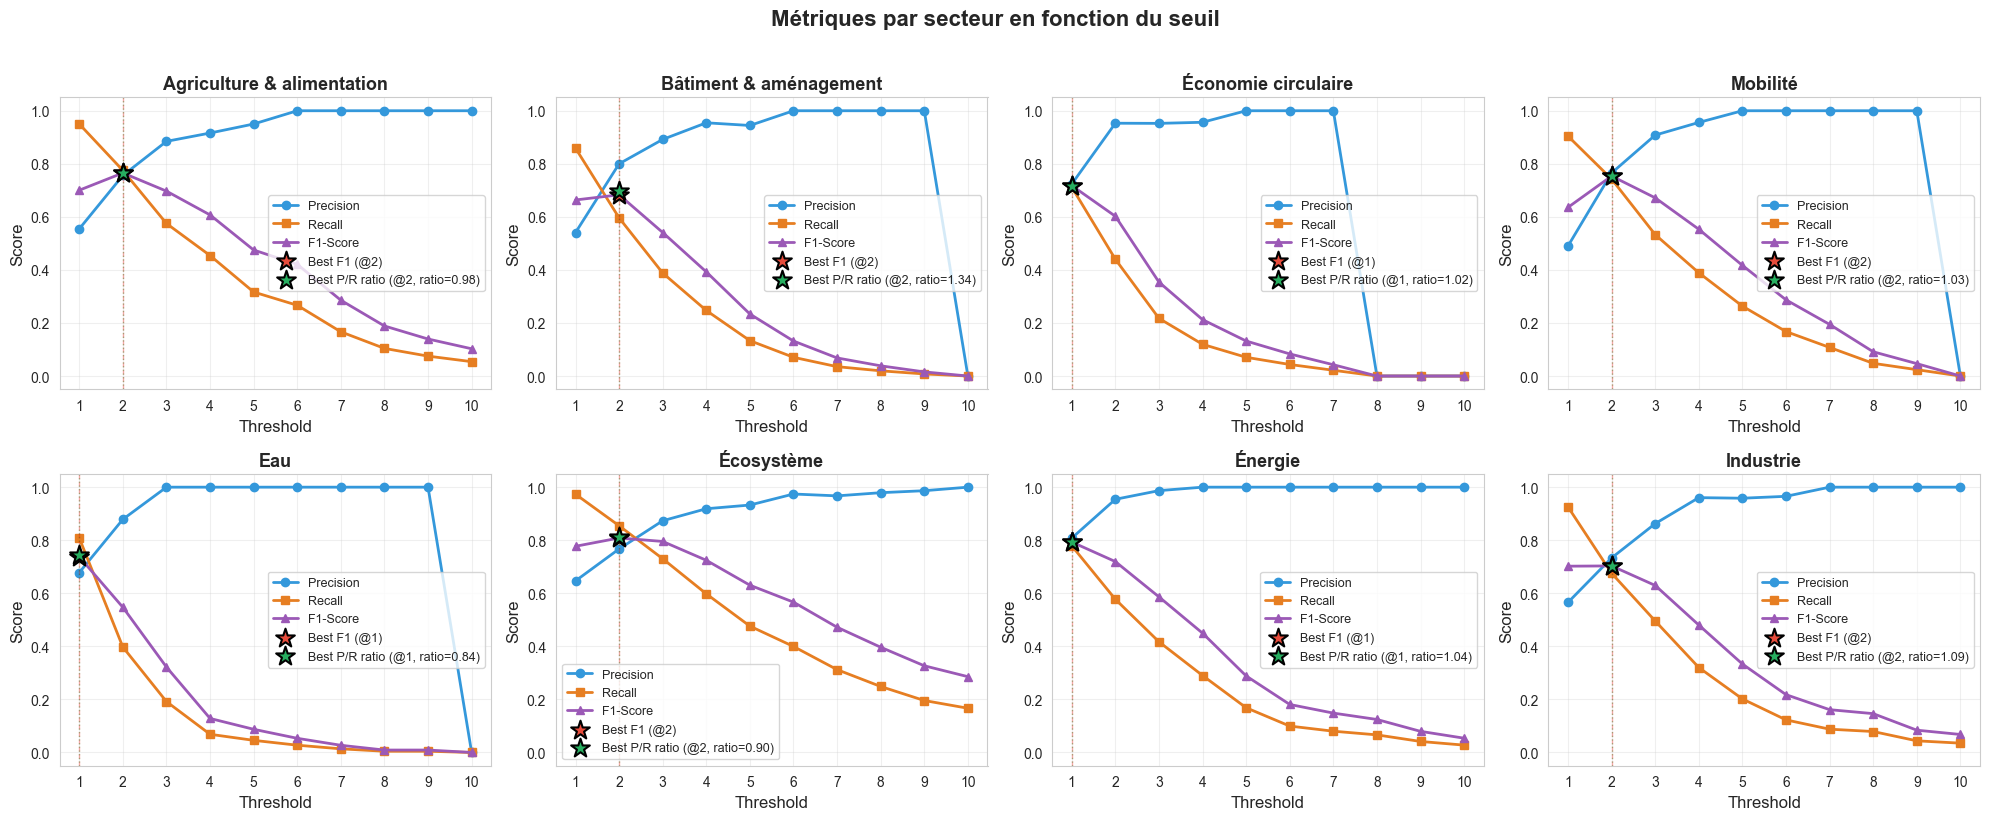

In [7]:
plot_threshold_metrics_by_sector(results_secteurs)

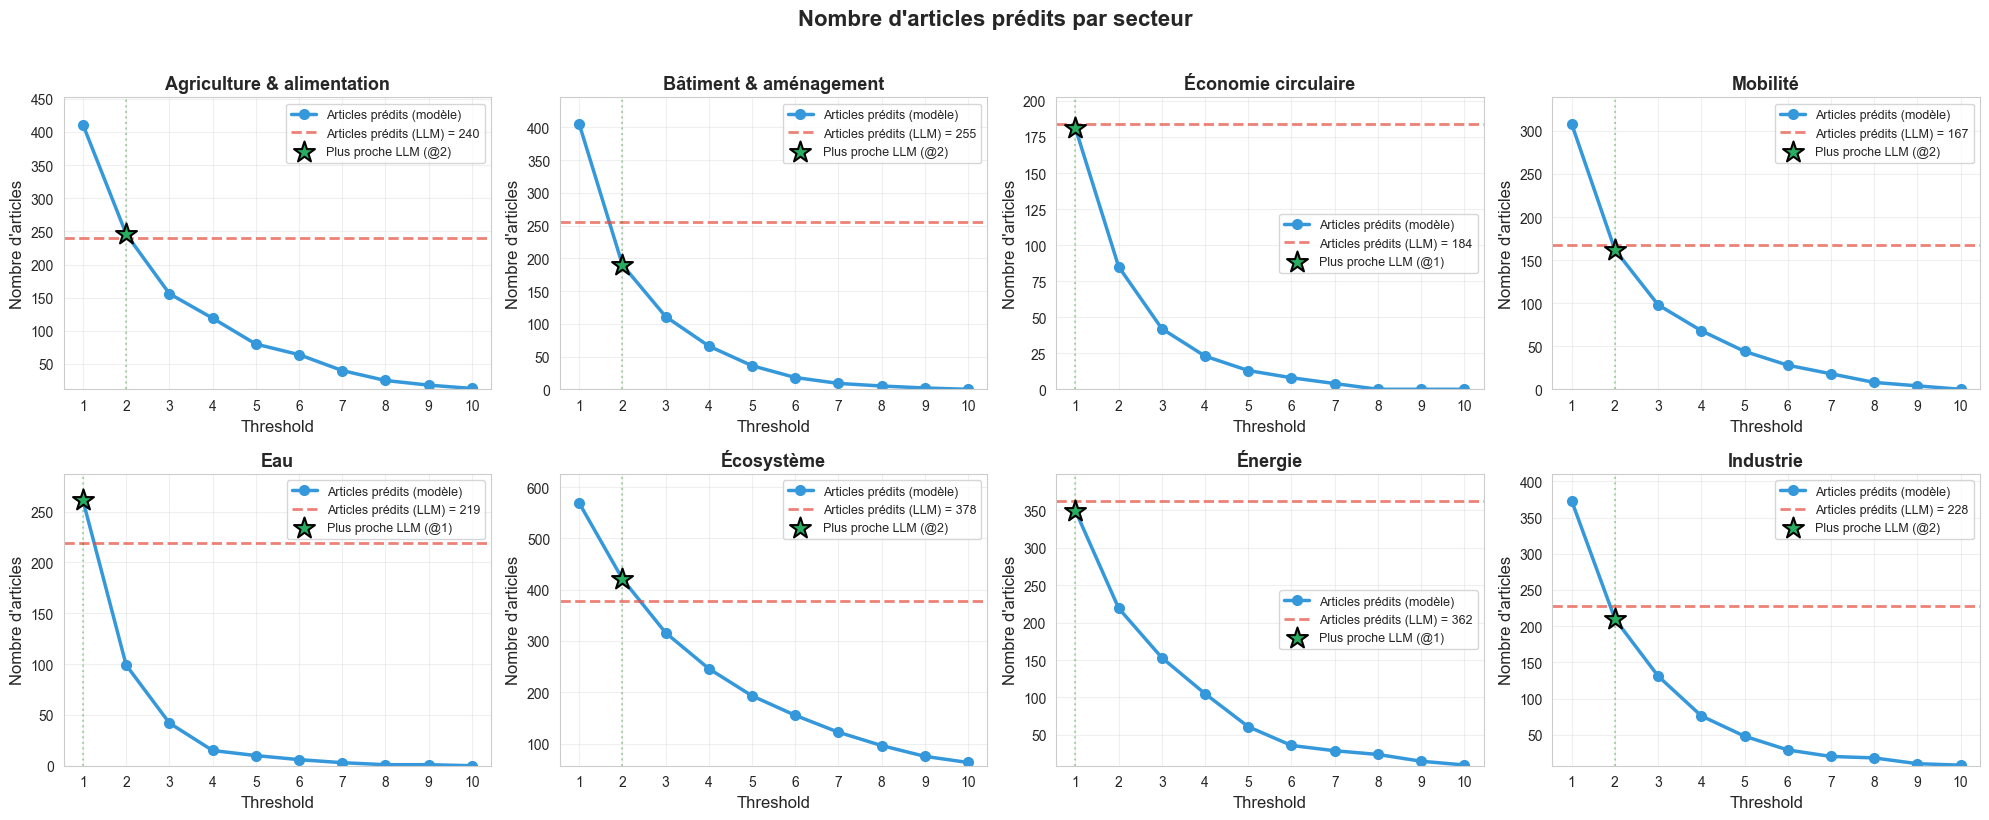

In [8]:
plot_nb_predicted_articles_by_sector(results_secteurs)